# Leakage-Free Severity Estimation on the Parkinson's Telemonitoring Dataset

A single, self-contained notebook reproducing the **complete** analysis: every model family that
was run for the study, plus the five contributions. The only external file needed is
`parkinsons_updrs.data` (UCI Parkinson's Telemonitoring) in the working directory.

**Contributions (the centre of the work):**
1. **Patient-mean oracle** &mdash; identity-only baseline (zero voice features) that reproduces the literature's near-perfect scores.
2. **Diversity ablation** &mdash; at fixed recording volume, generalisation is bounded by the number of *patients*, not clips.
3. **Aggregation negative result** &mdash; per-patient feature averages help on training patients but *hurt* unseen ones.
4. **Three-regime taxonomy** &mdash; leaky / within-subject / cold-start.
5. **Few-shot personalization** &mdash; a handful of labelled visits drive a new patient's error from the cold-start floor to the oracle.

**Model coverage:** linear (LogReg, Ridge, Huber, SVR), tree ensembles (RandomForest, ExtraTrees),
gradient boosting (XGBoost, LightGBM, GradientBoosting), and neural networks
(MLP, deeper MLP, and an FT-Transformer-lite feature-attention model).

## 0. Setup and imports

`torch` is needed only for the neural-network section; everything else runs without it.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression, Ridge, HuberRegressor
from sklearn.svm import SVR
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              ExtraTreesRegressor, RandomForestRegressor, GradientBoostingRegressor)
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
from sklearn.metrics import (accuracy_score, f1_score, balanced_accuracy_score,
                             roc_auc_score, confusion_matrix)
import xgboost as xgb, lightgbm as lgb
from imblearn.over_sampling import SMOTE, BorderlineSMOTE
try:
    import torch, torch.nn as nn; HAVE_TORCH = True; torch.set_num_threads(4)
except Exception:
    HAVE_TORCH = False; print('torch not available - neural section will be skipped')

SEED = 42; np.random.seed(SEED)
DATA_PATH = 'data/raw/parkinsons_updrs.data'

## 1. Load the dataset

Oxford / UCI Parkinson's Telemonitoring: **5,875 sustained-vowel recordings** from **42 early-stage
patients** (~140 each) over six months; 16 dysphonia measures plus demographics; targets are
`motor_UPDRS` and `total_UPDRS`.

In [2]:
raw_map = {
    'Jitter(%)':'jitter','Jitter(Abs)':'jitter_abs','Jitter:RAP':'jitter_rap','Jitter:PPQ5':'jitter_ppq5',
    'Jitter:DDP':'jitter_ddp','Shimmer':'shimmer','Shimmer(dB)':'shimmer_db','Shimmer:APQ3':'shimmer_apq3',
    'Shimmer:APQ5':'shimmer_apq5','Shimmer:APQ11':'shimmer_apq11','Shimmer:DDA':'shimmer_dda',
    'NHR':'nhr','HNR':'hnr','RPDE':'rpde','DFA':'dfa','PPE':'ppe'}
RAW16 = list(raw_map.values())
df = pd.read_csv(DATA_PATH).rename(columns={'subject#':'subject_id'}).rename(columns=raw_map)
print(len(df),'recordings,',df.subject_id.nunique(),'patients')
print('motor_UPDRS mean=%.2f std=%.2f' % (df.motor_UPDRS.mean(), df.motor_UPDRS.std()))

5875 recordings, 42 patients
motor_UPDRS mean=21.30 std=8.13


## 2. Severity targets

- **3-class** (Hoehn & Yahr aligned): Mild `<20`, Moderate `[20,30)`, Severe `>=30`.
- **Binary**: mild vs not-mild at motor-UPDRS **20**.

In [3]:
y_reg = df['motor_UPDRS'].values
groups = df['subject_id'].values
y2 = (y_reg >= 20).astype(int)
y3 = np.where(y_reg < 20, 0, np.where(y_reg < 30, 1, 2))
print('binary counts :', np.bincount(y2))
print('3-class counts:', np.bincount(y3))

binary counts : [2760 3115]
3-class counts: [2760 2116  999]


## 3. Feature engineering

**39 base features:** 3 demographics + 16 raw voice + 11 log jitter/shimmer + 4 ratios + 5 age
interactions. A separate **80-column patient-aggregate** block (per-patient mean/std/min/max/median
of the 16 raw features) is used only for the aggregation experiments (Sections 10 and 13).

In [4]:
LOG_FEATS = ['jitter','jitter_abs','jitter_rap','jitter_ppq5','jitter_ddp',
             'shimmer','shimmer_db','shimmer_apq3','shimmer_apq5','shimmer_apq11','shimmer_dda']

def build_features(df):
    X = pd.DataFrame(index=df.index)
    X['age'],X['sex'],X['test_time'] = df['age'],df['sex'],df['test_time']        # demographics (3)
    for c in RAW16: X[c] = df[c]                                                  # raw voice (16)
    for c in LOG_FEATS: X['log_'+c] = np.log1p(df[c])                             # log variants (11)
    X['shimmer_over_jitter']=df['shimmer']/(df['jitter']+1e-9)                    # ratios (4)
    X['nhr_over_hnr']=df['nhr']/(df['hnr']+1e-9)
    X['ppe_dfa']=df['ppe']*df['dfa']; X['rpde_ppe']=df['rpde']*df['ppe']
    X['age_sq']=df['age']**2                                                      # age interactions (5)
    X['age_ppe']=df['age']*df['ppe']; X['age_hnr']=df['age']*df['hnr']
    X['age_dfa']=df['age']*df['dfa']; X['age_shimmer']=df['age']*df['shimmer']
    return X

def patient_agg(df, groups):
    out = pd.DataFrame(index=df.index); t = df.copy(); t['__g']=groups
    for f in RAW16:
        gb = t.groupby('__g')[f]
        for stat in ['mean','std','min','max','median']:
            out['%s_%s'%(f,stat)] = t['__g'].map(getattr(gb,stat)()).values
    return out.fillna(0.0)

X = build_features(df); Xv = X.values
Xagg = pd.concat([X, patient_agg(df, groups)], axis=1).values   # 39 + 80 = 119
print('base:', X.shape, '  augmented:', Xagg.shape)

base: (5875, 39)   augmented: (5875, 119)


## 4. Patient-disjoint cross-validation (the leakage check)

`StratifiedGroupKFold` keeps every recording of a patient in one fold; we assert **zero patient
overlap** per fold. Stratify on the per-patient majority of the binary label (regression/binary
tracks) or the 3-class label (3-class track).

In [5]:
def patient_majority(y_cls, groups):
    t = pd.DataFrame({'g':groups,'y':y_cls})
    maj = t.groupby('g')['y'].agg(lambda s: s.value_counts().idxmax())
    return t['g'].map(maj).values

def make_folds(y_cls, groups, n_splits=5):
    strat = patient_majority(y_cls, groups)
    return list(StratifiedGroupKFold(n_splits, shuffle=True, random_state=SEED).split(np.zeros(len(groups)), strat, groups))

folds  = make_folds(y2, groups)    # binary / regression
folds3 = make_folds(y3, groups)    # 3-class
for k,(tr,te) in enumerate(folds):
    assert not (set(groups[tr]) & set(groups[te])), f'LEAK in fold {k}'
print('no patient overlap in any fold; test patients per fold:',
      [len(set(groups[te])) for _,te in folds])

no patient overlap in any fold; test patients per fold: [9, 8, 8, 8, 9]


## 5. Models

All factories return fresh, unfitted estimators with the study's hyper-parameters. Trees use raw
features; linear models / SVR / nets are scaled per fold. Class balancing via `class_weight`,
`scale_pos_weight`, or `sample_weight` as each library supports.

### 5.1 Classifiers

In [6]:
def clf_logreg():        return LogisticRegression(max_iter=2000, class_weight='balanced', random_state=SEED)
def clf_random_forest(): return RandomForestClassifier(500, min_samples_leaf=2, class_weight='balanced', random_state=SEED, n_jobs=-1)
def clf_extra_trees():   return ExtraTreesClassifier(700, class_weight='balanced', random_state=SEED, n_jobs=-1)
def clf_lightgbm():      return lgb.LGBMClassifier(n_estimators=800, num_leaves=63, learning_rate=0.04, class_weight='balanced', random_state=SEED, n_jobs=-1, verbose=-1)
def clf_xgboost(y_train=None, binary=False):
    spw = None
    if binary and y_train is not None:
        cw = compute_class_weight('balanced', classes=np.array([0,1]), y=y_train); spw = cw[1]/cw[0]
    return xgb.XGBClassifier(n_estimators=600, max_depth=6, learning_rate=0.05, colsample_bytree=0.85,
                             scale_pos_weight=spw, random_state=SEED, n_jobs=-1)

### 5.2 Regressors

In [7]:
def reg_ridge():            return Ridge(alpha=1.0)
def reg_huber():            return HuberRegressor(epsilon=1.35, max_iter=500)
def reg_svr():              return SVR(kernel='rbf', C=1.0, epsilon=1.0)
def reg_extra_trees():      return ExtraTreesRegressor(700, min_samples_leaf=2, random_state=SEED, n_jobs=-1)  # winner
def reg_random_forest():    return RandomForestRegressor(500, random_state=SEED, n_jobs=-1)
def reg_xgboost():          return xgb.XGBRegressor(n_estimators=600, max_depth=6, learning_rate=0.05, subsample=0.85, colsample_bytree=0.85, random_state=SEED, n_jobs=-1)
def reg_lightgbm():         return lgb.LGBMRegressor(n_estimators=800, num_leaves=63, learning_rate=0.04, random_state=SEED, n_jobs=-1, verbose=-1)
def reg_gradient_boosting():return GradientBoostingRegressor(n_estimators=400, random_state=SEED)

### 5.3 Neural networks (PyTorch)

An MLP (Linear &rarr; BatchNorm &rarr; GELU &rarr; Dropout blocks) used at two depths, and an
**FT-Transformer-lite** that tokenises each scalar feature and attends over them with a CLS token.
Trained with AdamW + cosine schedule + gradient clipping and class-weighted cross-entropy.

In [8]:
if HAVE_TORCH:
    class MLP(nn.Module):
        def __init__(self, d_in, hidden, n_out, p):
            super().__init__(); layers=[]; prev=d_in
            for h in hidden: layers += [nn.Linear(prev,h), nn.BatchNorm1d(h), nn.GELU(), nn.Dropout(p)]; prev=h
            layers += [nn.Linear(prev,n_out)]; self.net = nn.Sequential(*layers)
        def forward(self,x): return self.net(x)

    class FeatureAttention(nn.Module):   # FT-Transformer-lite
        def __init__(self, n_feat, n_out, d=16, heads=4, layers=2):
            super().__init__()
            self.value = nn.Parameter(torch.randn(n_feat,d)*0.02)
            self.bias  = nn.Parameter(torch.zeros(n_feat,d))
            self.cls   = nn.Parameter(torch.randn(1,1,d)*0.02)
            enc = nn.TransformerEncoderLayer(d_model=d, nhead=heads, dim_feedforward=4*d, dropout=0.1, batch_first=True)
            self.encoder = nn.TransformerEncoder(enc, num_layers=layers); self.head = nn.Linear(d,n_out)
        def forward(self,x):
            b=x.shape[0]; tok = x.unsqueeze(-1)*self.value.unsqueeze(0)+self.bias.unsqueeze(0)
            seq = torch.cat([self.cls.expand(b,-1,-1), tok], dim=1)
            return self.head(self.encoder(seq)[:,0])

    def train_eval_nn(kind, y, n_out, folds, hidden=None, dropout=0.3, epochs=40, lr=2e-3):
        accs,f1s,baccs,aucs,fsev=[],[],[],[],[]
        for tr,te in folds:
            np.random.seed(SEED); torch.manual_seed(SEED)
            sc = StandardScaler()
            a = torch.tensor(sc.fit_transform(Xv[tr]), dtype=torch.float32)
            b = torch.tensor(sc.transform(Xv[te]), dtype=torch.float32)
            yt = torch.tensor(y[tr], dtype=torch.long)
            cw = torch.tensor(compute_class_weight('balanced', classes=np.arange(n_out), y=y[tr]), dtype=torch.float32)
            model = FeatureAttention(Xv.shape[1], n_out) if kind=='attn' else MLP(Xv.shape[1], hidden, n_out, dropout)
            opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
            sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
            loss_fn = nn.CrossEntropyLoss(weight=cw); n=len(a); bs=512
            for _ in range(epochs):
                model.train(); perm=torch.randperm(n)
                for i in range(0,n,bs):
                    idx=perm[i:i+bs]; opt.zero_grad()
                    loss=loss_fn(model(a[idx]), yt[idx]); loss.backward()
                    nn.utils.clip_grad_norm_(model.parameters(),1.0); opt.step()
                sched.step()
            model.eval()
            with torch.no_grad(): prob=torch.softmax(model(b),1).numpy()
            pred=prob.argmax(1); yte=y[te]
            accs.append(accuracy_score(yte,pred)); f1s.append(f1_score(yte,pred,average='macro'))
            baccs.append(balanced_accuracy_score(yte,pred))
            if n_out==2: aucs.append(roc_auc_score(yte,prob[:,1]) if len(np.unique(yte))>1 else 0.5)
            else: fsev.append(f1_score(yte,pred,labels=[2],average='macro',zero_division=0))
        out={'macro_f1':np.mean(f1s),'balanced_acc':np.mean(baccs)}
        out.update({'auc':np.mean(aucs)} if n_out==2 else {'f1_severe':np.mean(fsev)})
        return out

## 6. Evaluation routines

Per-fold preprocessing is fit on train only. `eval_classifier` supports optional scaling,
Yeo-Johnson, PCA, balanced sample weights, and factories that take the training labels (XGBoost).
`eval_reg_threshold` fits a regressor and thresholds predictions at 20.

In [9]:
THRESHOLD=20.0; sd=lambda x: float(np.std(x, ddof=1))
import inspect
def _takes_y(fn):
    try: return len(inspect.signature(fn).parameters)>=1
    except (TypeError,ValueError): return False

def prep(Xtr,Xte,scale=False,yeo=False,pca=None):
    if scale: s=StandardScaler(); Xtr=s.fit_transform(Xtr); Xte=s.transform(Xte)
    if yeo:   p=PowerTransformer(); Xtr=p.fit_transform(Xtr); Xte=p.transform(Xte)
    if pca:   c=PCA(n_components=pca, random_state=0); Xtr=c.fit_transform(Xtr); Xte=c.transform(Xte)
    return Xtr,Xte

def eval_classifier(M, y, folds, make_model, n_classes, scale=False, yeo=False, pca=None, bsw=False):
    F1,AUC,FSEV,BACC=[],[],[],[]
    for tr,te in folds:
        a,b = prep(M[tr],M[te],scale,yeo,pca)
        model = make_model(y[tr]) if _takes_y(make_model) else make_model()
        if bsw: model.fit(a,y[tr],sample_weight=compute_sample_weight('balanced',y[tr]))
        else:   model.fit(a,y[tr])
        pred=model.predict(b); yte=y[te]
        F1.append(f1_score(yte,pred,average='macro')); BACC.append(balanced_accuracy_score(yte,pred))
        if n_classes==2: AUC.append(roc_auc_score(yte,model.predict_proba(b)[:,1]) if len(np.unique(yte))>1 else 0.5)
        else: FSEV.append(f1_score(yte,pred,labels=[2],average='macro',zero_division=0))
    r={'macro_f1':np.mean(F1),'balanced_acc':np.mean(BACC)}
    r.update({'auc':np.mean(AUC)} if n_classes==2 else {'f1_severe':np.mean(FSEV)})
    return r

def eval_reg_threshold(M, y_reg, folds, make_model, yeo=False, return_oof=False):
    MAE,RMSE,AUC,per=[],[],[],[]; oof=np.full(len(y_reg),np.nan); oy=np.zeros(len(y_reg),int)
    for k,(tr,te) in enumerate(folds):
        a,b = prep(M[tr],M[te],yeo=yeo)
        m=make_model(); m.fit(a,y_reg[tr]); pred=m.predict(b)
        err=pred-y_reg[te]
        mae=float(np.mean(np.abs(err))); rmse=float(np.sqrt(np.mean(err**2)))
        yt=(y_reg[te]>=THRESHOLD).astype(int)
        auc=roc_auc_score(yt,pred) if len(np.unique(yt))>1 else 0.5
        MAE.append(mae); RMSE.append(rmse); AUC.append(auc); oof[te]=pred; oy[te]=yt
        per.append((k,round(mae,2),round(rmse,2),round(auc,3)))
    r={'mae':np.mean(MAE),'mae_std':sd(MAE),'rmse':np.mean(RMSE),'rmse_std':sd(RMSE),
       'auc':np.mean(AUC),'auc_std':sd(AUC),'per_fold':per}
    if return_oof:
        yh=(oof>=THRESHOLD).astype(int)
        r['oof_confusion']=confusion_matrix(oy,yh).tolist(); r['oof_auc']=roc_auc_score(oy,oof)
    return r

## 7. Three-class severity (all models)

Classical + boosting classifiers and all three neural nets. Macro-F1 is low across the board
(~0.29&ndash;0.36); deep models do not beat trees. The severe class (only 6 patients) is the bottleneck.

In [10]:
specs3 = [('LogReg',clf_logreg,dict(scale=True)), ('RandomForest',clf_random_forest,{}),
          ('ExtraTrees',clf_extra_trees,{}), ('LightGBM',clf_lightgbm,{}),
          ('XGBoost',clf_xgboost,dict(bsw=True))]
for name,mk,kw in specs3:
    r=eval_classifier(Xv,y3,folds3,mk,3,**kw)
    print('%-13s macroF1=%.3f  balAcc=%.3f  F1severe=%.3f'%(name,r['macro_f1'],r['balanced_acc'],r['f1_severe']))

LogReg        macroF1=0.293  balAcc=0.314  F1severe=0.186


RandomForest  macroF1=0.371  balAcc=0.384  F1severe=0.154


ExtraTrees    macroF1=0.323  balAcc=0.346  F1severe=0.026


LightGBM      macroF1=0.341  balAcc=0.362  F1severe=0.121


XGBoost       macroF1=0.342  balAcc=0.372  F1severe=0.163


In [11]:
if HAVE_TORCH:
    for name,kind,hid,dp,ep in [('MLP',         'mlp',[128,64],0.3,40),
                                ('MLP_deep',    'mlp',[256,128,64],0.4,50),
                                ('FeatureAttn', 'attn',None,None,25)]:
        r=train_eval_nn(kind,y3,3,folds3,hidden=hid,dropout=dp or 0.3,epochs=ep)
        print('%-13s macroF1=%.3f  balAcc=%.3f  F1severe=%.3f'%(name,r['macro_f1'],r['balanced_acc'],r['f1_severe']))
# (neural nets are CPU-heavy; reduce epochs for a quick pass)

MLP           macroF1=0.360  balAcc=0.376  F1severe=0.313


MLP_deep      macroF1=0.355  balAcc=0.363  F1severe=0.245


FeatureAttn   macroF1=0.269  balAcc=0.284  F1severe=0.208


## 8. Binary severity (all models)

Direct binary classifiers (XGBoost uses `scale_pos_weight`) and the binary MLP. Direct
classification tops out near AUC 0.55 &mdash; below the regression-then-threshold route in Section 9.

In [12]:
specs2 = [('LogReg',clf_logreg,dict(scale=True)), ('RandomForest',clf_random_forest,{}),
          ('ExtraTrees',clf_extra_trees,{}), ('LightGBM',clf_lightgbm,{}),
          ('XGBoost',lambda ytr: clf_xgboost(ytr,binary=True),{})]
for name,mk,kw in specs2:
    r=eval_classifier(Xv,y2,folds,mk,2,**kw)
    print('%-13s AUC=%.3f  macroF1=%.3f  balAcc=%.3f'%(name,r['auc'],r['macro_f1'],r['balanced_acc']))
if HAVE_TORCH:
    r=train_eval_nn('mlp',y2,2,folds,hidden=[128,64],dropout=0.3,epochs=40)
    print('%-13s AUC=%.3f  macroF1=%.3f  balAcc=%.3f'%('MLP',r['auc'],r['macro_f1'],r['balanced_acc']))

LogReg        AUC=0.421  macroF1=0.442  balAcc=0.452


RandomForest  AUC=0.482  macroF1=0.457  balAcc=0.479


ExtraTrees    AUC=0.553  macroF1=0.544  balAcc=0.565


LightGBM      AUC=0.522  macroF1=0.476  balAcc=0.509


XGBoost       AUC=0.525  macroF1=0.508  balAcc=0.534


MLP           AUC=0.558  macroF1=0.510  balAcc=0.518


## 9. Regression then threshold (all regressors) + the winning pipeline

Predict the continuous score, threshold at 20. **Extra Trees + Yeo-Johnson** is the winner
(MAE ~7.39, AUC ~0.63). Linear/SVR are scaled; trees use raw features; `*_yeo` rows apply the transform.

In [13]:
reg_specs = [('Ridge',reg_ridge,True), ('Huber',reg_huber,True), ('SVR',reg_svr,True),
             ('ExtraTrees',reg_extra_trees,False), ('ExtraTrees_yeo',reg_extra_trees,True),
             ('RandomForest',reg_random_forest,False), ('XGBoost',reg_xgboost,False),
             ('LightGBM',reg_lightgbm,False),
             ('GradientBoosting',reg_gradient_boosting,False)]
for name,mk,yeo in reg_specs:
    r=eval_reg_threshold(Xv,y_reg,folds,mk,yeo=yeo)
    print('%-17s MAE=%.2f  AUC=%.3f'%(name,r['mae'],r['auc']))

Ridge             MAE=9.41  AUC=0.464


Huber             MAE=9.88  AUC=0.456


SVR               MAE=8.23  AUC=0.490


ExtraTrees        MAE=7.41  AUC=0.633


ExtraTrees_yeo    MAE=7.38  AUC=0.629


RandomForest      MAE=8.07  AUC=0.613


XGBoost           MAE=7.98  AUC=0.598


LightGBM          MAE=8.24  AUC=0.591


GradientBoosting  MAE=8.30  AUC=0.581


In [14]:
# winning pipeline with per-fold detail and pooled out-of-fold confusion
win = eval_reg_threshold(Xv, y_reg, folds, reg_extra_trees, yeo=True, return_oof=True)
print('WINNER  ExtraTrees + Yeo-Johnson -> threshold 20')
print('  MAE  = %.2f (sd %.2f)   RMSE = %.2f (sd %.2f)   AUC = %.3f (sd %.3f)'
      % (win['mae'],win['mae_std'],win['rmse'],win['rmse_std'],win['auc'],win['auc_std']))
print('  per-fold (fold, MAE, RMSE, AUC):', win['per_fold'])
# no-skill RMSE for reference (predicting the global mean)
floor_rmse = float(np.sqrt(np.mean((y_reg - y_reg.mean())**2)))
print('  no-skill RMSE (global mean) = %.2f  -> RMSE sits just above the floor on the hard folds' % floor_rmse)
print('  pooled OOF confusion:', win['oof_confusion'], '  OOF AUC=%.3f'%win['oof_auc'])

WINNER  ExtraTrees + Yeo-Johnson -> threshold 20
  MAE  = 7.38 (sd 1.69)   RMSE = 9.38 (sd 1.88)   AUC = 0.629 (sd 0.183)
  per-fold (fold, MAE, RMSE, AUC): [(0, 5.19, 6.81, 0.72), (1, 6.29, 8.27, 0.75), (2, 7.53, 9.81, 0.798), (3, 9.44, 11.66, 0.507), (4, 8.47, 10.34, 0.37)]
  no-skill RMSE (global mean) = 8.13  -> RMSE sits just above the floor on the hard folds
  pooled OOF confusion: [[1778, 982], [1603, 1512]]   OOF AUC=0.575


## 10. Literature-driven variants

Reproductions of recipes from prior work, all under the honest split: a Box-Cox (Yeo-Johnson)
transform, Box-Cox + PCA(20), and the **patient-aggregated** feature block fed to several models.
The patient-aggregate variants are where leakage normally sneaks back in (see Section 13).

In [15]:
lit = [('A_yeo_ExtraTrees',      Xv,   clf_extra_trees, dict(yeo=True)),
       ('B_yeo_PCA20_ExtraTrees',  Xv,   clf_extra_trees, dict(yeo=True, pca=20)),
       ('C1_PatAgg_LightGBM',      Xagg, clf_lightgbm, {}),
       ('C2_PatAgg_ExtraTrees',    Xagg, clf_extra_trees, {}),
       ('C3_PatAgg_XGBoost',       Xagg, lambda ytr: clf_xgboost(ytr,binary=True), {}),
       ('D_PatAgg_yeo_ExtraTrees', Xagg, clf_extra_trees, dict(yeo=True))]
for name,M,mk,kw in lit:
    r=eval_classifier(M,y2,folds,mk,2,**kw)
    print('%-26s AUC=%.3f  macroF1=%.3f'%(name,r['auc'],r['macro_f1']))

A_yeo_ExtraTrees           AUC=0.536  macroF1=0.535


B_yeo_PCA20_ExtraTrees     AUC=0.497  macroF1=0.478


C1_PatAgg_LightGBM         AUC=0.489  macroF1=0.414


C2_PatAgg_ExtraTrees       AUC=0.459  macroF1=0.435


C3_PatAgg_XGBoost          AUC=0.460  macroF1=0.452


D_PatAgg_yeo_ExtraTrees    AUC=0.461  macroF1=0.448


## 11. ★ Contribution 1 — Patient-mean oracle (the leakage ceiling)

Predict each recording as the mean of that patient's *other* recordings &mdash; **zero voice features**.
This is the best any model can do once it has seen the patient (i.e. under leakage). It reaches
**R&sup2; ~0.916** (MAE ~1.76), inside the literature's 0.90&ndash;0.999 range, while the honest floor is R&sup2;=0.

In [16]:
r2=lambda yt,yp:1-np.sum((yt-yp)**2)/np.sum((yt-yt.mean())**2)
mae=lambda yt,yp:np.mean(np.abs(yt-yp)); rmse=lambda yt,yp:np.sqrt(np.mean((yt-yp)**2))
y=y_reg.astype(float); g=groups
within=pd.Series(y).groupby(g).std(ddof=1).mean(); across=pd.Series(y).groupby(g).mean().std(ddof=1)
print('within-patient std=%.2f  across-patient std=%.2f  ratio=%.3f'%(within,across,within/across))
sums=pd.Series(y).groupby(g).transform('sum').values; cnts=pd.Series(y).groupby(g).transform('count').values
oracle=(sums-y)/(cnts-1)
print('ORACLE (no voice): MAE=%.2f RMSE=%.2f R2=%.3f'%(mae(y,oracle),rmse(y,oracle),r2(y,oracle)))
floor=np.full_like(y,y.mean())
print('FLOOR  (global mean): MAE=%.2f RMSE=%.2f R2=%.3f'%(mae(y,floor),rmse(y,floor),r2(y,floor)))

within-patient std=2.08  across-patient std=7.88  ratio=0.264
ORACLE (no voice): MAE=1.75 RMSE=2.35 R2=0.916
FLOOR  (global mean): MAE=6.96 RMSE=8.13 R2=0.000


## 12. ★ Contribution 2 — Diversity ablation (patients vs recordings)

Left: keep all 42 patients, vary recordings-per-patient &rarr; plateaus by ~30. Right: hold total
volume fixed (~2000) and vary the number of patients &rarr; AUC climbs from ~0.51 to ~0.76. **Patient
diversity is the binding constraint.** (Tree counts reduced so the sweeps finish in minutes.)

In [17]:
rng=np.random.default_rng(SEED)
def fit_winner(trc,te,n_trees=300):
    p=PowerTransformer(); a=p.fit_transform(Xv[trc]); b=p.transform(Xv[te])
    m=ExtraTreesRegressor(n_trees,min_samples_leaf=2,random_state=SEED,n_jobs=-1); m.fit(a,y_reg[trc])
    pred=m.predict(b); yt=(y_reg[te]>=20).astype(int)
    return (roc_auc_score(yt,pred) if len(np.unique(yt))>1 else 0.5), float(np.mean(np.abs(pred-y_reg[te])))

rec_caps=[10,30,60,100,None]; rec_auc=[]
for cap in rec_caps:
    a_=[]
    for tr,te in folds:
        keep=[]
        for pid in np.unique(g[tr]):
            idx=tr[g[tr]==pid]
            if cap and len(idx)>cap: idx=rng.choice(idx,cap,replace=False)
            keep.append(idx)
        a_.append(fit_winner(np.concatenate(keep),te)[0])
    rec_auc.append(np.mean(a_)); print('recordings/patient=%4s  AUC=%.3f'%(str(cap),rec_auc[-1]))

recordings/patient=  10  AUC=0.559


recordings/patient=  30  AUC=0.611


recordings/patient=  60  AUC=0.632


recordings/patient= 100  AUC=0.638


recordings/patient=None  AUC=0.628


In [18]:
VOL=2000; Ks=[8,16,24,33]; div_auc=[]; div_err=[]
for K in Ks:
    reps=[]
    for rep in range(3):
        r=np.random.default_rng(100+rep); per=[]
        for tr,te in folds[:3]:
            pats=r.choice(np.unique(g[tr]), min(K,len(np.unique(g[tr]))), replace=False); cap=max(1,VOL//K); keep=[]
            for pid in pats:
                idx=tr[g[tr]==pid]
                if len(idx)>cap: idx=r.choice(idx,cap,replace=False)
                keep.append(idx)
            per.append(fit_winner(np.concatenate(keep),te)[0])
        reps.append(np.mean(per))
    div_auc.append(np.mean(reps)); div_err.append(np.std(reps))
    print('train patients=%2d (~%d rec each)  AUC=%.3f +/- %.3f'%(K,VOL//K,div_auc[-1],div_err[-1]))

train patients= 8 (~250 rec each)  AUC=0.505 +/- 0.070


train patients=16 (~125 rec each)  AUC=0.682 +/- 0.071


train patients=24 (~83 rec each)  AUC=0.645 +/- 0.031


train patients=33 (~60 rec each)  AUC=0.759 +/- 0.001


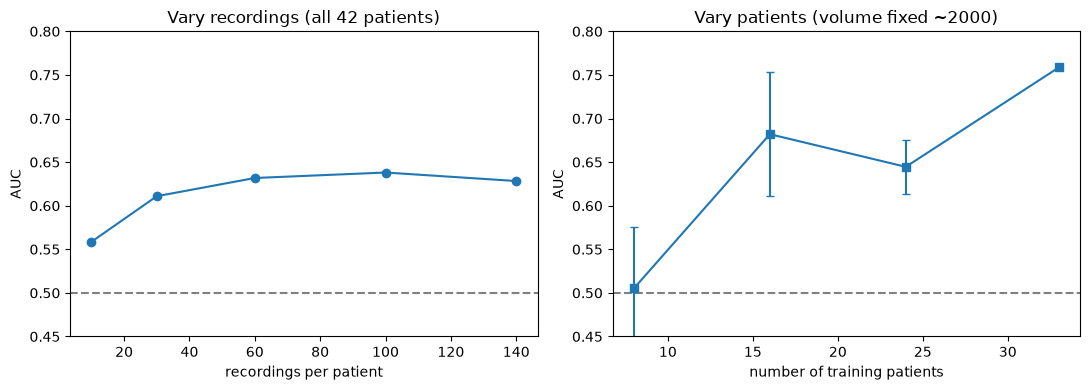

In [19]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(11,4))
ax1.plot([10,30,60,100,140],rec_auc,'o-'); ax1.axhline(.5,ls='--',c='gray')
ax1.set_title('Vary recordings (all 42 patients)'); ax1.set_xlabel('recordings per patient'); ax1.set_ylabel('AUC'); ax1.set_ylim(.45,.8)
ax2.errorbar(Ks,div_auc,yerr=div_err,fmt='s-',capsize=3); ax2.axhline(.5,ls='--',c='gray')
ax2.set_title('Vary patients (volume fixed ~2000)'); ax2.set_xlabel('number of training patients'); ax2.set_ylabel('AUC'); ax2.set_ylim(.45,.8)
plt.tight_layout(); plt.show()

## 13. ★ Contribution 3 — Patient-aggregated features: a negative result

Append each patient's own mean/std/min/max/median (80 cols &rarr; 119). Under leakage it looks
helpful; under honest evaluation it **hurts**, because the aggregates are a per-patient fingerprint
the trees memorise and cannot transfer to unseen patients.

In [20]:
for label,M in [('base 39',Xv),('augmented 119',Xagg)]:
    r=eval_reg_threshold(M,y_reg,folds,reg_extra_trees,yeo=False)
    print('%-14s test AUC=%.3f  MAE=%.2f'%(label,r['auc'],r['mae']))

base 39        test AUC=0.633  MAE=7.41


augmented 119  test AUC=0.573  MAE=7.21


## 14. ★ Contribution 5 — Few-shot personalization (cold-start → oracle)

**The constructive result.** For each *unseen* test patient, reveal *k* of their recordings as
calibration, use them only to set a subject-specific offset on the cold-start regressor, and
evaluate on the patient's remaining recordings. No test label enters training. Error falls from
the cold-start floor (~7.3) toward the oracle (~1.76): one visit reaches ~2.9, five to ten approach
the oracle. A trivial running-mean of the same labels does as well, showing personalization works
by anchoring to the patient's level, not by better voice decoding. The oracle is the *k*→∞ limit.

In [21]:
ks=[0,1,2,3,5,10,20]; n_rep=25
curve={k:[] for k in ks}; cmean={k:[] for k in ks}
rngp=np.random.default_rng(SEED)
for tr,te in folds:
    p=PowerTransformer(); a=p.fit_transform(Xv[tr]); b=p.transform(Xv[te])
    m=ExtraTreesRegressor(700,min_samples_leaf=2,random_state=SEED,n_jobs=-1); m.fit(a,y[tr])
    base=m.predict(b); tg,ty=g[te],y[te]
    for pid in np.unique(tg):
        idx=np.where(tg==pid)[0]
        if len(idx)<25: continue
        for k in ks:
            if k==0: curve[0].append(np.abs(base[idx]-ty[idx]).mean()); continue
            cc,mm=[],[]
            for _ in range(n_rep):
                cal=rngp.choice(idx,k,replace=False); ev=np.setdiff1d(idx,cal)
                off=np.mean(ty[cal]-base[cal])
                cc.append(np.abs((base[ev]+off)-ty[ev]).mean()); mm.append(np.abs(ty[cal].mean()-ty[ev]).mean())
            curve[k].append(np.mean(cc)); cmean[k].append(np.mean(mm))
print('%3s %18s %18s'%('k','voice+intercept','calibration-mean'))
for k in ks:
    cm = np.mean(cmean[k]) if k>0 else float('nan')
    print('%3d %18.2f %18.2f'%(k, np.mean(curve[k]), cm))

  k    voice+intercept   calibration-mean
  0               7.30                nan
  1               2.94               2.33
  2               2.53               2.06
  3               2.41               1.99
  5               2.30               1.88
 10               2.24               1.84
 20               2.20               1.81


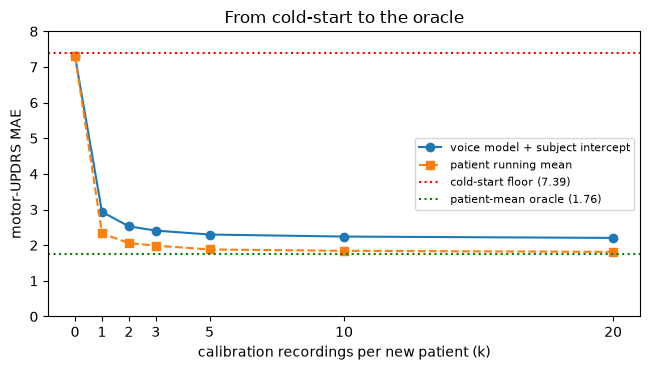

In [22]:
kk=ks; v=[np.mean(curve[k]) for k in ks]; c=[v[0]]+[np.mean(cmean[k]) for k in ks[1:]]
plt.figure(figsize=(6.6,3.8))
plt.plot(kk,v,'o-',label='voice model + subject intercept')
plt.plot(kk,c,'s--',label='patient running mean')
plt.axhline(7.39,ls=':',c='r',label='cold-start floor (7.39)')
plt.axhline(1.76,ls=':',c='g',label='patient-mean oracle (1.76)')
plt.xlabel('calibration recordings per new patient (k)'); plt.ylabel('motor-UPDRS MAE')
plt.title('From cold-start to the oracle'); plt.ylim(0,8); plt.xticks(kk); plt.legend(fontsize=8); plt.tight_layout(); plt.show()

## 15. SMOTE for the minority (severe) class

Applied **inside each training fold only**. Modest lift to severe-F1 (~0.08 &rarr; ~0.17); it adds
synthetic *recordings*, not the *patients* that Section 12 showed to be the real constraint.

In [23]:
def smote_3class(mode):
    F1,FSEV=[],[]
    for tr,te in folds3:
        Xtr,ytr=Xv[tr],y3[tr]
        if mode=='baseline':
            clf=RandomForestClassifier(400,min_samples_leaf=2,class_weight='balanced',random_state=SEED,n_jobs=-1)
        else:
            sm=SMOTE(random_state=SEED) if mode=='smote' else BorderlineSMOTE(random_state=SEED)
            Xtr,ytr=sm.fit_resample(Xtr,ytr)
            clf=RandomForestClassifier(400,min_samples_leaf=2,random_state=SEED,n_jobs=-1)
        clf.fit(Xtr,ytr); pred=clf.predict(Xv[te])
        F1.append(f1_score(y3[te],pred,average='macro')); FSEV.append(f1_score(y3[te],pred,labels=[2],average='macro',zero_division=0))
    print('%-12s macroF1=%.3f  F1severe=%.3f'%(mode,np.mean(F1),np.mean(FSEV)))
for mode in ['baseline','smote','borderline']: smote_3class(mode)

baseline     macroF1=0.369  F1severe=0.150


smote        macroF1=0.377  F1severe=0.174


borderline   macroF1=0.371  F1severe=0.168


## 16. ★ Contribution 4 — Three-regime taxonomy

| Regime | What is held out | Typical reported result | What it really measures |
|---|---|---|---|
| **Leaky** | nothing (recordings shuffled) | R&sup2; 0.90&ndash;0.999, ~99% acc | patient recall (see oracle, &sect;11) |
| **Within-subject** | a patient's later visit | RMSE ~2.5, MAE <1 | short-term temporal continuity |
| **Cold-start** (this work) | whole unseen patients | MAE ~7.4, AUC ~0.63 | genuine voice-to-severity signal |

The personalization curve (&sect;14) connects these into a **continuum**: a patient moves from
cold-start to within-subject as labelled visits accumulate, with the oracle as the limit. The honest
frontier is weak for new patients, but a few calibration visits make tracking *known* patients accurate.